### Ovarlaying CD103+ cDC2 signatures from Stefani Springer and Fiona Chatterjee.  

In [1]:
#load packages I need
import os
import tools
import scanpy as sc
import pandas as pd
import dandelion as ddl
from tqdm import tqdm
import matplotlib.pyplot as plt
import scanpy.external as sce
from matplotlib.pyplot import rc_context
import seaborn as sns

/home/s4436039/miniforge3/envs/envpy26/lib/python3.10/site-packages/nxviz/__init__.py:33: UserWarning: 
nxviz has a new API! Version 0.7.4 onwards, the old class-based API is being
deprecated in favour of a new API focused on advancing a grammar of network
graphics. If your plotting code depends on the old API, please consider
pinning nxviz at version 0.7.4, as the new API will break your old code.

To check out the new API, please head over to the docs at
https://ericmjl.github.io/nxviz/ to learn more. We hope you enjoy using it!

(This deprecation message will go away in version 1.0.)



In [2]:
#set current directory 
os.chdir('/scratch/user/s4436039/scdata/Myeloid_Objects')
os.getcwd()

'/scratch/user/s4436039/scdata/Myeloid_Objects'

In [3]:
# read in data
data_DC = sc.read_h5ad('20250617_AllDC_bbknn.h5ad')
data = sc.read_h5ad('NRclean_clustered2.h5ad')
data_DC2 = sc.read_h5ad('20250629_DC2_bbknn_clustered2.h5ad')

In [4]:
# Set colours for NR_annotations_simple plot:
data_DC.uns["NR_annotations_simple_colors"] = ['#e377c2', '#aa40fc', '#8c564b']  

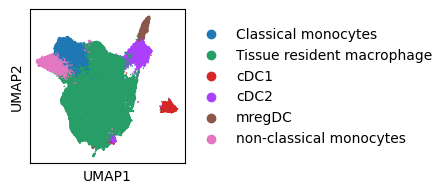

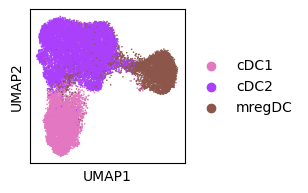

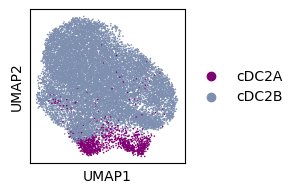

In [5]:
#export high res umap
with plt.rc_context({"figure.figsize": (2, 2)}):
    sc.pl.umap(data, color="MyeloidAPC_Subsets", size=5, title="")
    sc.pl.umap(data_DC, color="NR_annotations_simple", size=5, title="")
    sc.pl.umap(data_DC2, color="cDC2_A-B", size=5, title="")

In [3]:
data_DC2 = sc.read_h5ad('20250629_DC2_bbknn_clustered2.h5ad')

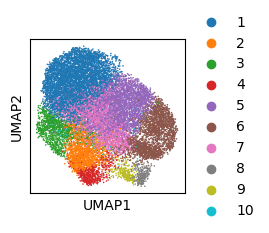

In [4]:
with plt.rc_context({"figure.figsize": (2, 2)}):
    sc.pl.umap(data_DC2, color="cDC2_Atlas_Subclusters", size=5, title="")

In [5]:
# Assign DC2 subclusters new:
data_DC2.obs["cDC2_annotated"] = data_DC2.obs["cDC2_Atlas_Subclusters"].map(
    {
        "1": "DC3-like cDC2",
        "2": "undefined cDC2",
        "3": "IL-1B cDC2",
        "4": "CD207/LTB cDC2",
        "5": "classical cDC2",
        "6": "ascites classical cDC2",
        "7": "classical cDC2",
        "8": "CD207/LTB cDC2",
        "9": "CD207/LTB cDC2",
        "10": "CD207/LTB cDC2",
    }
)
###check naming from meeting

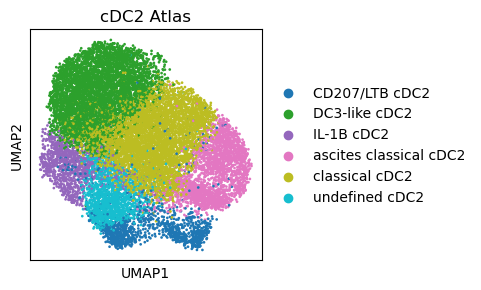

In [8]:
with plt.rc_context({"figure.figsize": (3, 3)}):
    sc.pl.umap(data_DC2, color="cDC2_annotated", size=15, title="cDC2 Atlas", palette="tab10")

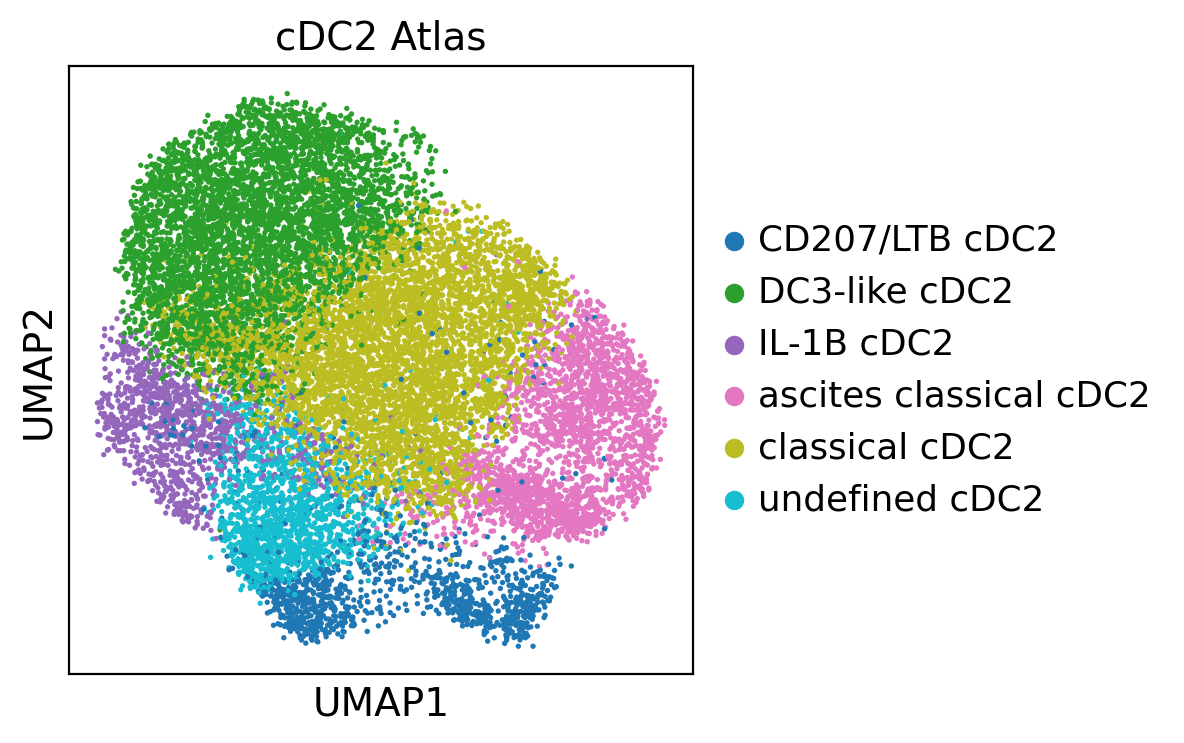

In [27]:
with plt.rc_context({"figure.figsize": (4, 4)}):
    sc.pl.umap(data_DC2, color="cDC2_annotated", size=15, title="cDC2 Atlas", palette="tab10", save="_NR_Atlas_Spranger_annots_DC2_v2.pdf")

## Define gene lists from Fiona 
* lists provided were mouse gene lists, these were manually converted to human (I capitalised and then checked each existed on genecards and any that had alternate names I changed). 
* One gene had to be removed as it does not have a human ortholog: AU020206 from the CD103 DC2 vs classical DC2 list

In [7]:
CD103_v_DC = ['JAML','B4GALT6','IL18RAP','IMMP2L','HTRA3','PPP1R14A','CTNND2','CHN2','NAPSA','FFAR2','CYP4F8','SIGLEC8','KIAA1671','AP1S2','NEURL3','STK17B','IL1R2','LIFR','EMB','GPR141','ITGAX','ARHGAP15','TREML2','IFNGR1','FGR','CORO2A','CD300A','PVT1','PTPN12','CD244','SH2D1B','CCR1','FGFR1','CLEC6A','NDST1','PRKCB','ELMO1','CTSS','CDH17','GCNT1','RIN3','HLA-DRB5','CREB5','OTULINL','CYP4F3','HLA-DQA1','HLA-DOA','MMP12','RBM47','PICALM']
CD103_v_DC2 = ['ID2','PPP1R14A','JAML','WDFY4','ITGAE','FGFR1','FKBP5','LIFR','ARHGAP15','IMMP2L','STK17B','PRKCB','DPP4','IL18RAP','P2RY14','B4GALT6','INPP5D','DOCK10','CTNND2','MAN2B1','RNASE6','CORO2A','ADAM23','AP1S2','CST3','CDH17','TCEA3','CARD11','SHTN1','BCL2L11','SORL1','GPR141','WNK1','PLEKHA5','ELMO1','LIMS1','OTULINL','ACTN1','ST6GAL1','FBXL20','FNBP1','MCTP1','SULT1A1','RBM47','HLA-DOA','DPY19L1','PDCD4','IPCEF1','CD84']
CD103_v_DC1 = ['CREB5','CCR1','CLEC6A','ATRNL1','SIRPA','LILRB4','IL1R2','TREML2','TYROBP','S100A6','B4GALT6','CYBB','APP','CTSS','FFAR2','JAML','CFP','IL18RAP','NAPSA','ZNF609','TMEM176B','ZEB2','MALT1','FGR','NCF2','CERS6','CDH1','IMMP2L','EMB','COXFA4L3','TMEM176A','PTPN12','KLRD1','ITGAX','HTRA3','TGM2','ITGAM','CD33','FCER1G','SIGLEC8','HLA-DMB','ANKH','FOSL2','NEURL3','CTSA','MDH2','NDST1','CTSZ','NRIP1','ATP6V0C']

In [8]:
# Define dictionary of gene sets
gene_sets = {
    "CD103_v_DC": CD103_v_DC,
    "CD103_v_DC2": CD103_v_DC2,
    "CD103_v_DC1": CD103_v_DC1
}

In [9]:
# Loop through each gene set and calculate the scores
for name, genes in gene_sets.items():
    sc.tl.score_genes(data, genes, score_name=name)

for name, genes in gene_sets.items():
    sc.tl.score_genes(data_DC, genes, score_name=name)

for name, genes in gene_sets.items():
    sc.tl.score_genes(data_DC2, genes, score_name=name)

NameError: name 'data' is not defined

In [28]:
for name, genes in gene_sets.items():
    sc.tl.score_genes(data_DC2, genes, score_name=name)

In [28]:
colour_vars_All = ["CD103_v_DC","CD103_v_DC2","CD103_v_DC1","MyeloidAPC_Subsets"]
colour_vars_DC = ["CD103_v_DC","CD103_v_DC2","CD103_v_DC1","NR_annotations_simple"]
colour_vars_DC2 = ["CD103_v_DC","CD103_v_DC2","CD103_v_DC1","cDC2_annotated"]

In [29]:
colour_vars_DC2 = ["CD103_v_DC","CD103_v_DC2","CD103_v_DC1","cDC2_annotated"]

In [14]:
sc.set_figure_params(dpi=100, dpi_save=700, vector_friendly=True, format='svg') #only run when exporting umaps (not heatmaps)

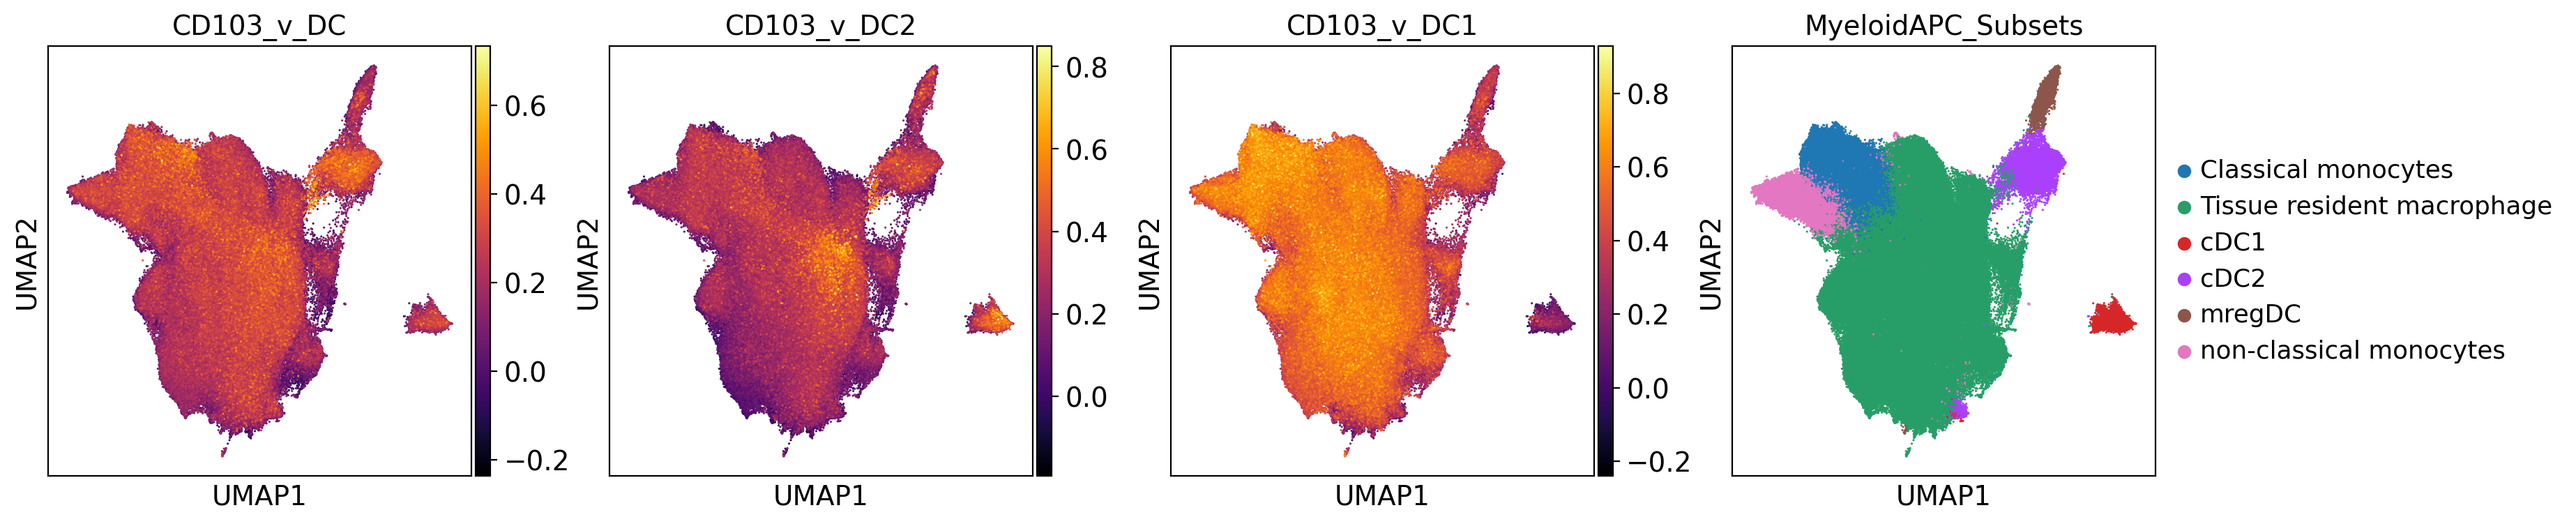

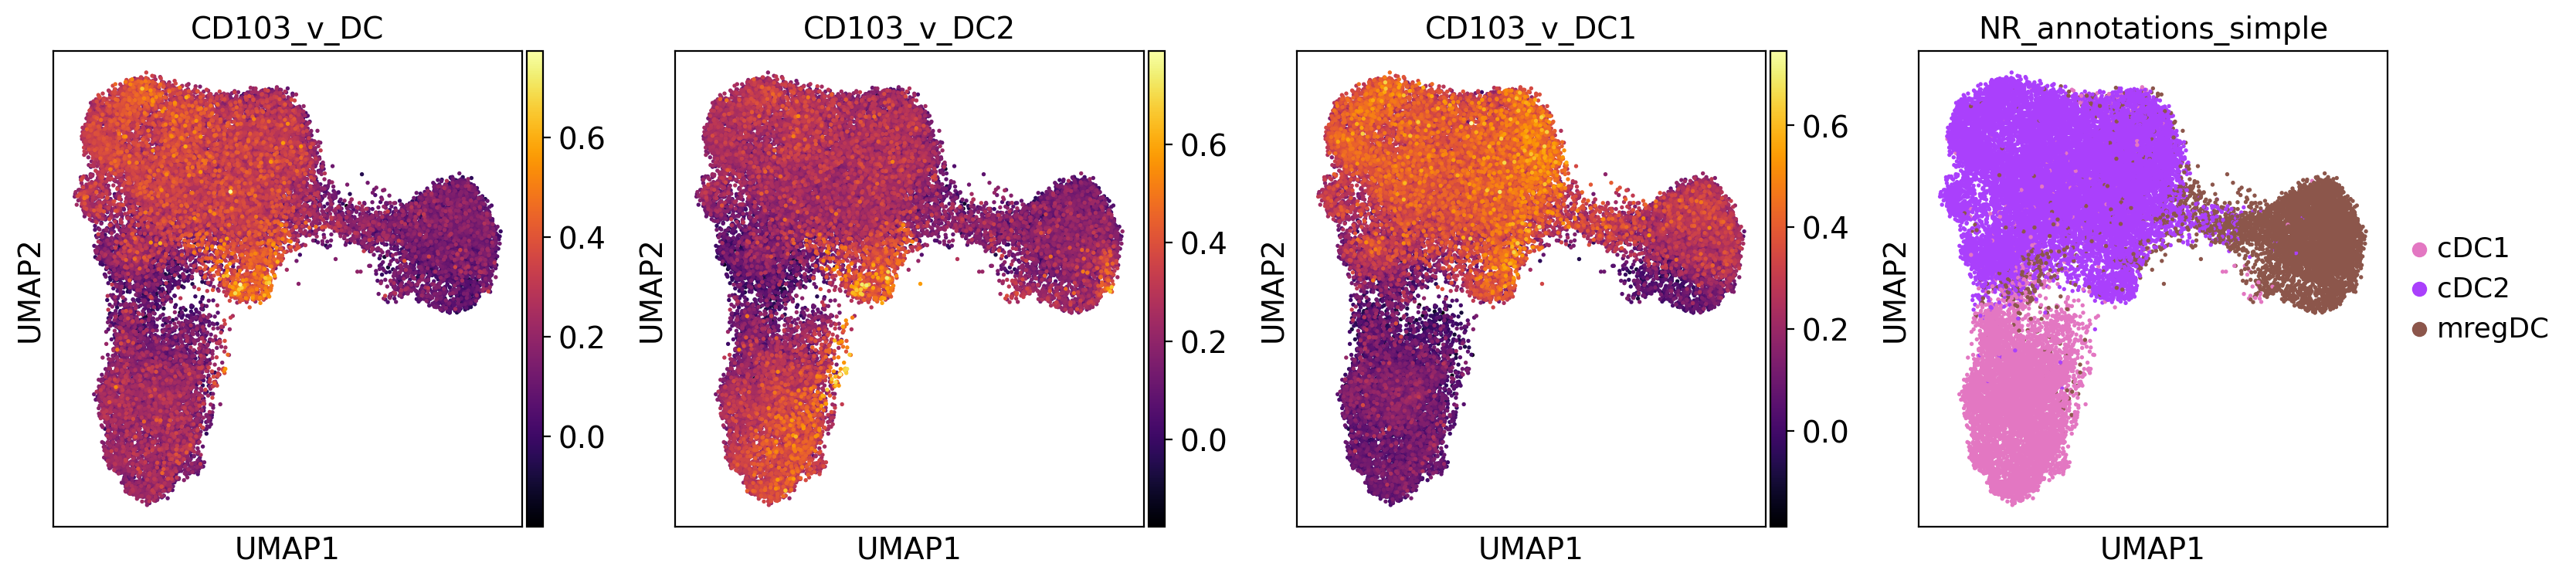

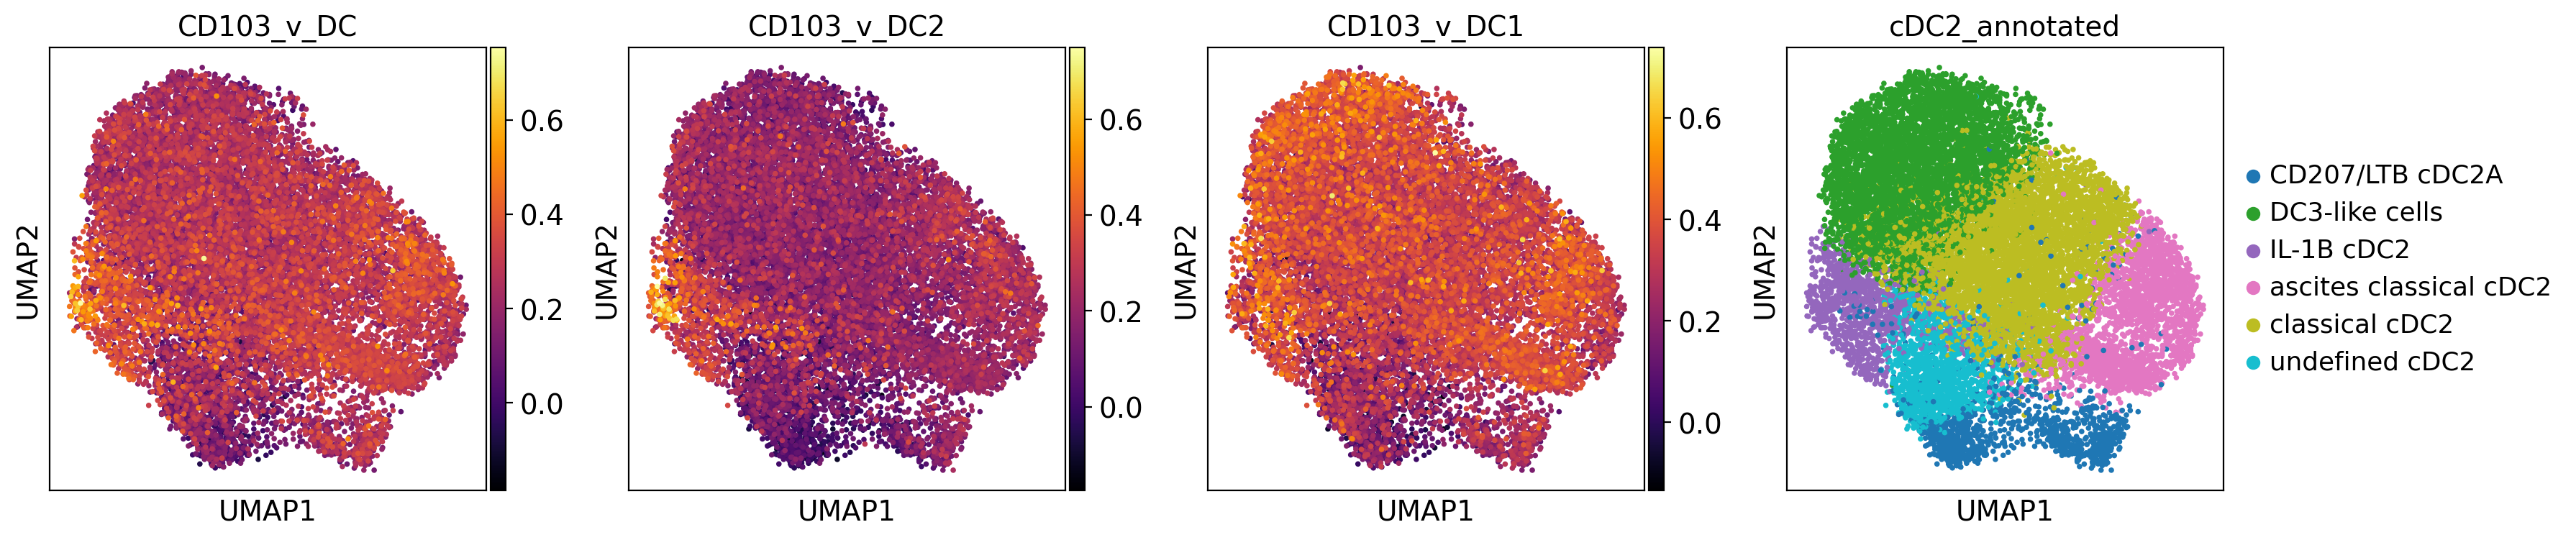

In [29]:
#plotting 
with plt.rc_context({"figure.figsize": (4, 4)}): 
    sc.pl.umap(data, color=colour_vars_All, ncols=4, size=5, cmap="inferno", save="_NR_Atlas_CD103_overlay_AllAtlas.pdf")
    sc.pl.umap(data_DC, color=colour_vars_DC, ncols=4, size=15, cmap="inferno", save="_NR_Atlas_CD103_overlay_AllDC.pdf")
    sc.pl.umap(data_DC2, color=colour_vars_DC2, ncols=4, size=30, cmap="inferno", save="_NR_Atlas_CD103_overlay_DC2.pdf")

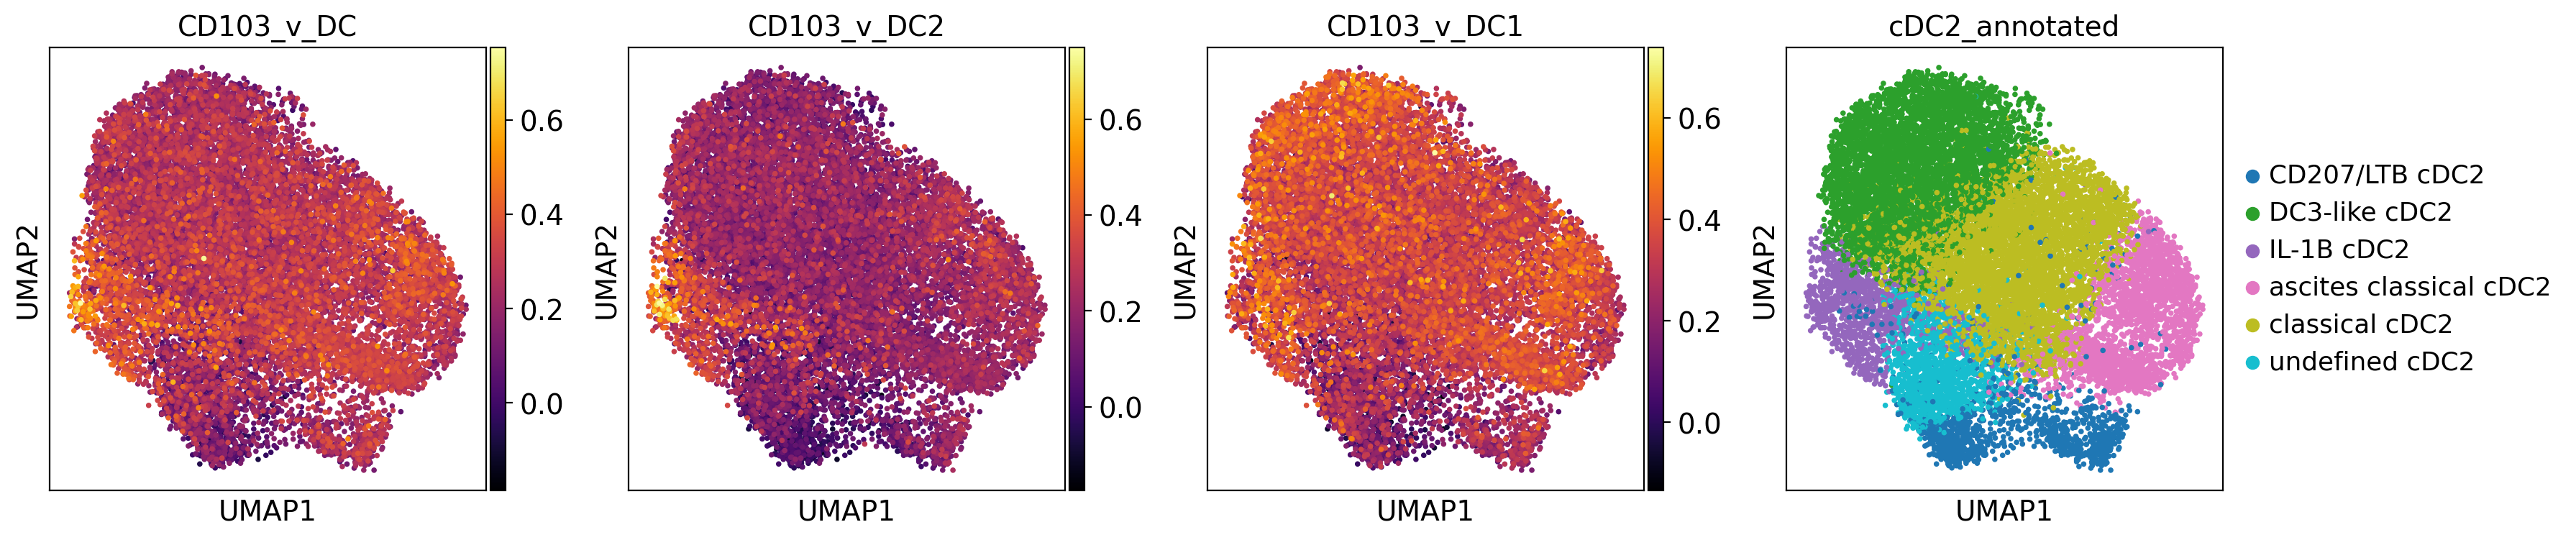

In [30]:
#plotting 
with plt.rc_context({"figure.figsize": (4, 4)}): 
    sc.pl.umap(data_DC2, color=colour_vars_DC2, ncols=4, size=30, cmap="inferno", save="_NR_Atlas_CD103sig_overlay_DC2_v2.pdf")

# Breakdown:

In [9]:
data_DC2_primary = data_DC2[data_DC2.obs["sample_type_major2"] == "primary tumour"]

In [10]:
# set colours for bar graph
colours10 = data_DC2.uns["cDC2_annotated_colors"]
clusters = data_DC2.obs["cDC2_annotated"].cat.categories
colour_dict = dict(zip(clusters, colours10))

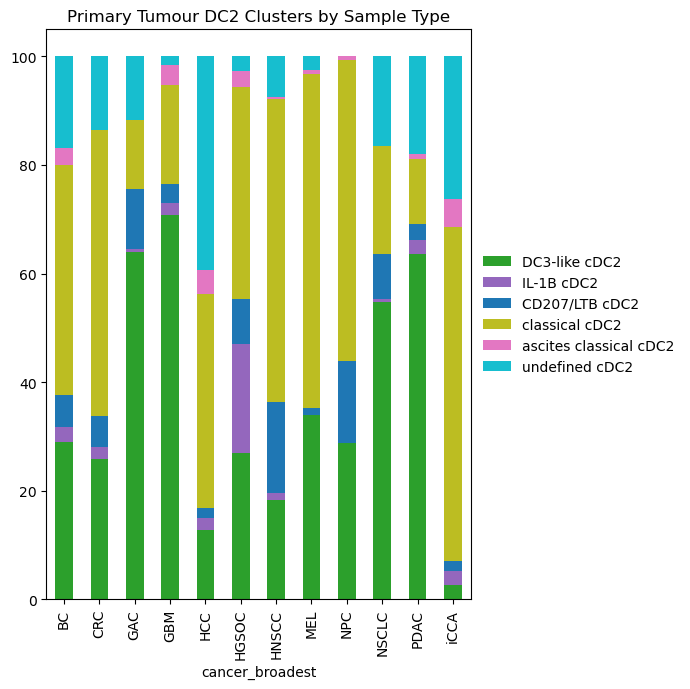

In [11]:
# plot stacked graph by cancer type for primary samples only
ct1 = pd.crosstab(data_DC2_primary.obs["cancer_broadest"], data_DC2_primary.obs["cDC2_annotated"])
ct1_pct = ct1.apply(lambda r: r / r.sum() * 100, axis=1)
ct1_pct = ct1_pct[["DC3-like cDC2","IL-1B cDC2","CD207/LTB cDC2","classical cDC2","ascites classical cDC2","undefined cDC2"]]
colours = [colour_dict[col] for col in ct1_pct.columns]
ct1_pct.plot.bar(stacked=True, figsize=(7,7), color=colours)
plt.legend(bbox_to_anchor=(1, 0.5), loc="center left", frameon=False)
plt.title("Primary Tumour DC2 Clusters by Sample Type")
plt.tight_layout()  
plt.savefig("barplot_DC2_Spranger_primary_cancer_type.pdf", format="pdf", bbox_inches="tight")
plt.show()


### Featureplots

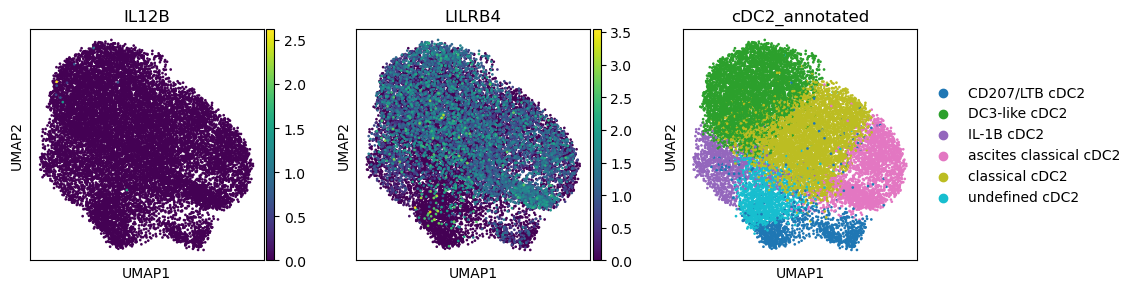

In [38]:
#plotting 
with plt.rc_context({"figure.figsize": (3, 3)}): 
    sc.pl.umap(data_DC2, color=["IL12B","LILRB4","cDC2_annotated"], ncols=3, size=15, save="_NR_Atlas_Spranger_features.pdf")